In [1]:
import matplotlib.pyplot as plt
import pynpoint.core.dataio
from pynpoint import *
from scripts.mcmc import residuals_rdi
import numpy as np
import emcee
import os
from pynpoint.util.image import (
    create_mask,
    polar_to_cartesian,
)
from astropy.io import fits


In [2]:
fwhm = 4.*0.01225  # (arcsec)
cent_size = fwhm  # (arcsec)
edge_size = 3.  # (arcsec)
extra_rot = 0.0  # (deg)
aperture = 5.*0.01225  # (arcsec)
pca_number = 12  # rdi H
psf_scaling = 7.94187*76.42*0.5

band = "H"
output_place = f'./output/{band}/'

working_place_in = f'./input/{band}/'

backend = emcee.backends.HDFBackend(
    os.path.join(working_place_in, "PynPoint_database.hdf5"),
    name=f'mcmc_pca_{pca_number:03.0f}_backend',
    read_only=False,
)

ndim = 3    # sep, ang (pa), mag

samples = backend.get_chain()


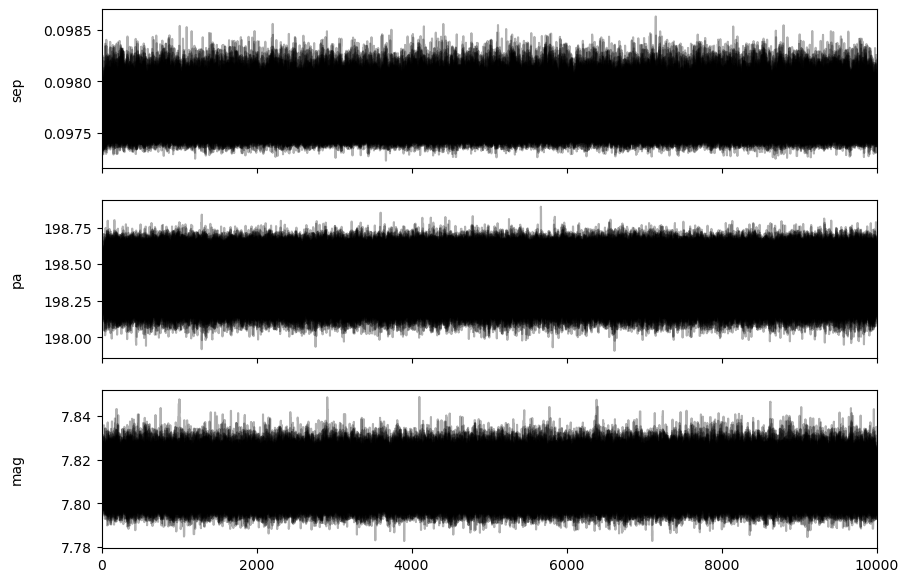

In [3]:
# plot initial chain
fig, axes = plt.subplots(ndim, figsize=(10,7), sharex=True)
labels = ['sep', 'pa', 'mag']

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)



In [4]:
burnin = int(0.2 * samples.shape[0])
samples = samples[burnin:, :, :].reshape((-1, ndim))

In [5]:
sep_percen = np.percentile(samples[:, 0], [16.0, 50.0, 84.0])
ang_percen = np.percentile(samples[:, 1], [16.0, 50.0, 84.0])
mag_percen = np.percentile(samples[:, 2], [16.0, 50.0, 84.0])

print("Median and uncertainties (20% removed as burnin):")

print(
    f"Separation (mas) = {1e3*sep_percen[1]:.2f} "
    f"(-{1e3*sep_percen[1]-1e3*sep_percen[0]:.2f} "
    f"+{1e3*sep_percen[2]-1e3*sep_percen[1]:.2f})"
)

print(
    f"Position angle (deg) = {ang_percen[1]:.2f} "
    f"(-{ang_percen[1]-ang_percen[0]:.2f} "
    f"+{ang_percen[2]-ang_percen[1]:.2f})"
)

print(
    f"Contrast (mag) = {mag_percen[1]:.2f} "
    f"(-{mag_percen[1]-mag_percen[0]:.2f} "
    f"+{mag_percen[2]-mag_percen[1]:.2f})"
)


mag_mean_err = 0.5 * (np.abs(mag_percen[1]-mag_percen[0]) + np.abs(mag_percen[2]-mag_percen[1]))
mag_max_err = np.max([np.abs(mag_percen[1]-mag_percen[0]), np.abs(mag_percen[2]-mag_percen[1])])

pa_max_err = np.max([np.abs(ang_percen[1]-ang_percen[0]), np.abs(ang_percen[2]-ang_percen[1])])
sep_max_err =  1e3*np.max([np.abs(sep_percen[1]-sep_percen[0]), np.abs(sep_percen[2]-sep_percen[1])])

print(mag_mean_err, mag_max_err)

mag_contrast = mag_percen[1]
sep = 1e3 * sep_percen[1]
pa = ang_percen[1]

print(pa_max_err, sep_max_err)
print(pa, sep)


Median and uncertainties (20% removed as burnin):
Separation (mas) = 97.69 (-0.14 +0.18)
Position angle (deg) = 198.38 (-0.12 +0.15)
Contrast (mag) = 7.81 (-0.01 +0.01)
0.0071188093657519325 0.00733554131463432
0.1456761277989358 0.1764802289408035
198.38256628944004 97.69224334917578


In [6]:
from uncertainties import ufloat, umath

def offset_to_seppa(dx, dy):
    pixscale = 0.01225
    TN_err = ufloat(0,0.04)
    sep_ufloat = umath.sqrt(dx**2 + dy**2) * pixscale
    pa_ufloat = umath.atan2(dx, -dy) + np.pi
    pa_ufloat = pa_ufloat * 180. / np.pi    # convert to degrees
    return sep_ufloat, pa_ufloat

def offset_to_seppa_witherror(dx, dy):
    pixscale = ufloat(0.01225, 0.00021)
    TN_err = ufloat(0,0.04)
    centering_error = 2.5e-3 / pixscale.n                               # centering error of 2.5 mas in pixels
    centering_error_uf = ufloat(0, centering_error)
    dx = dx + centering_error_uf
    dy = dy + centering_error_uf
    sep_ufloat = umath.sqrt(dx**2 + dy**2) * pixscale
    pa_ufloat = umath.atan2(dx, -dy) + np.pi + (TN_err / 180. * np.pi)
    pa_ufloat = pa_ufloat * 180. / np.pi    # convert to degrees
    return sep_ufloat, pa_ufloat

def seppa_to_offset(sep, pa):
    pixscale = 0.01225
    pa_rad = pa * np.pi / 180.
    theta = pa_rad - np.pi
    r = sep / pixscale
    dx = r * umath.sin(theta)
    dy = -r * umath.cos(theta)
    return dx, dy

sepuf = ufloat(sep_percen[1], 1e-3*sep_max_err)
pauf = ufloat(ang_percen[1], pa_max_err)
print("original sep and pa")
print(sepuf)
print(pauf)

xoff, yoff = seppa_to_offset(sepuf, pauf)
print("converted offset")
print(xoff)
print(yoff)

## correction from centering
#xoff_c = xoff - 0.5
#yoff_c = yoff - 0.5

# with error
print("converted back to sep and pa")
sepuf_n, pauf_n = offset_to_seppa_witherror(xoff, yoff)

print("reconverted pa and sep")
print(sepuf_n)
print(pauf_n)


## with error, corrected
#print("corrected and converted back to sep and pa")
#sepuf_n, pauf_n = offset_to_seppa_witherror(xoff_c, yoff_c)
#
#print("reconverted pa and sep")
#print(sepuf_n)
#print(pauf_n)

print("sep:", sepuf_n.n * 1e3, "+/-", sepuf_n.s*1e3)
print("pa:", pauf_n.n, "+/-", pauf_n.s)



original sep and pa
0.09769+/-0.00018
198.38+/-0.15
converted offset
2.515+/-0.020
-7.568+/-0.015
converted back to sep and pa
reconverted pa and sep
0.0977+/-0.0023
198.4+/-1.9
sep: 97.69224334917578 +/- 2.3119245366256367
pa: 198.38256628944 +/- 1.8599490619646264


In [7]:
# results mcmc
#sep = 0.10568
#ang = 195.67
#mag = 7.39
#print(sep, ang, mag)

# doesn't work
# plot residuals
#pipeline = Pypeline(working_place_in, './', output_place)
#
#images = pipeline.get_data(f'science_crop_tc_masked')
#ref_data = pipeline.get_data(f'ref_crop_tc_masked')
#psf = pipeline.get_data(f'flux_crop_mean')
#parang = np.array(pipeline.list_attributes('science')['PARANG'])
#pixscale = pipeline.list_attributes('science')['PIXSCALE']
#
#im_shape = images.shape[-2:]
#print("imshape", im_shape)
#mask = create_mask(im_shape[-2:], (cent_size, edge_size))
#print(parang, pixscale)
#pipeline.run()


In [8]:
#residual_im = residuals_rdi(np.array([sep_percen[1], ang_percen[1], mag_percen[1]]), images, ref_data,
#                            psf, mask, parang, psf_scaling, pixscale, pca_number,
#                            0.0, "mean")
#
#
#fits.writeto(f"output/{band}/mcmc_residuals_test.fits", residual_im, overwrite=True)

In [9]:
pipeline = Pypeline(working_place_in, './', output_place)
pipeline.list_attributes('offset')
offset = pipeline.get_data('offset')

print(pipeline.get_tags())

PynPoint v0.11.0

A new version (0.11.2) is available!

Want to stay informed about updates, bug fixes, and new features?
Please consider using the 'Watch' button on the Github page:
https://github.com/PynPoint/PynPoint

Working place: ./input/H/
Input place: ./
Output place: ./output/H/

Database: ./input/H/PynPoint_database.hdf5
Configuration: ./input/H/PynPoint_config.ini

Number of CPUs: 64
Number of threads: not set

----------------------------
Attribute overview of offset
----------------------------

Static attributes:

   - History: RemoveLinesModule = number of lines = (50, 50, 50, 50)

   - History: SystematicErrorModule = sep = 0.097, pa = 198.3, mag = 7.8

   - PIXSCALE = 0.01225

   - edge_size = 0.2

Non-static attributes:

   - FILES = [b'./input/H/sci.fits']

   - INDEX = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]

   - NFRAMES = [

In [10]:
print(offset.shape)
degrees = np.linspace(0, 359, 360, endpoint=True)
labels = ['dsep', 'dpa', 'dmag', 'dx', 'dy']
labels2 = ['sep', 'pa', 'mag', 'x', 'y']
print(offset[0,:])

(360, 5)
[-0.00451289  3.4481488   0.12535849 -0.50075417 -0.35332673]


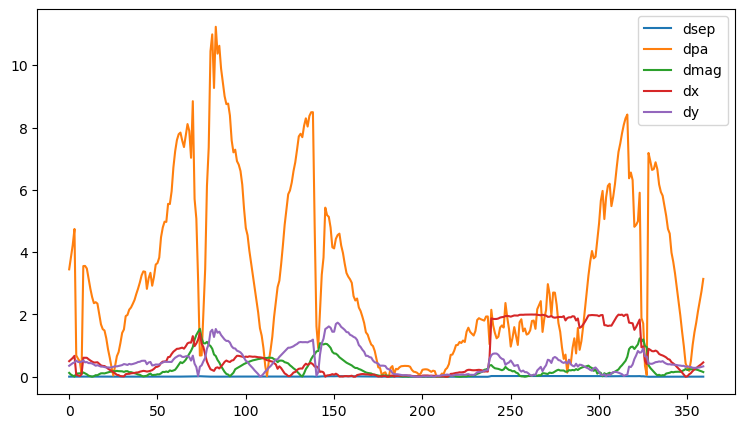

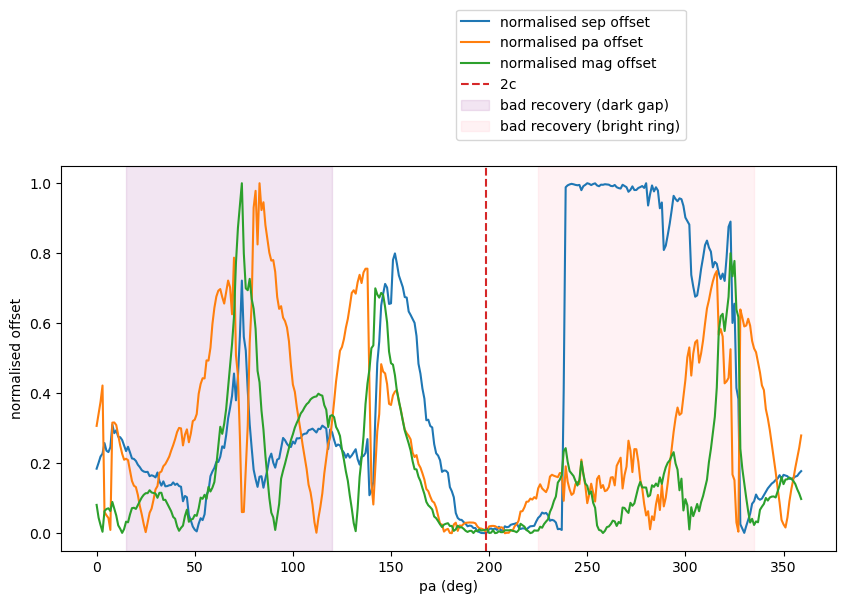

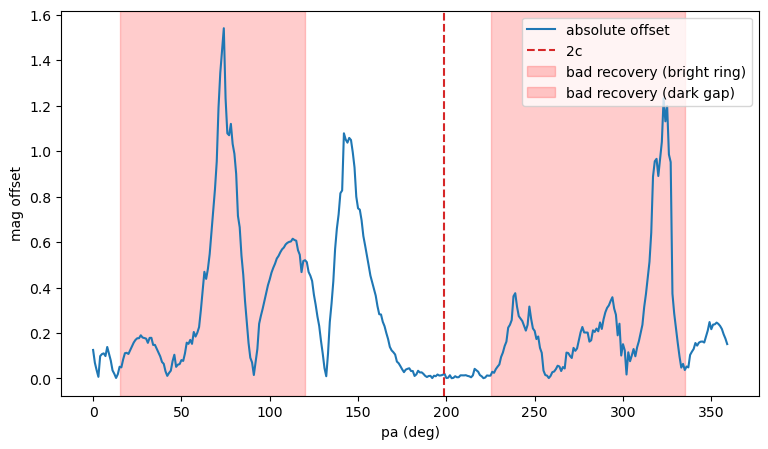

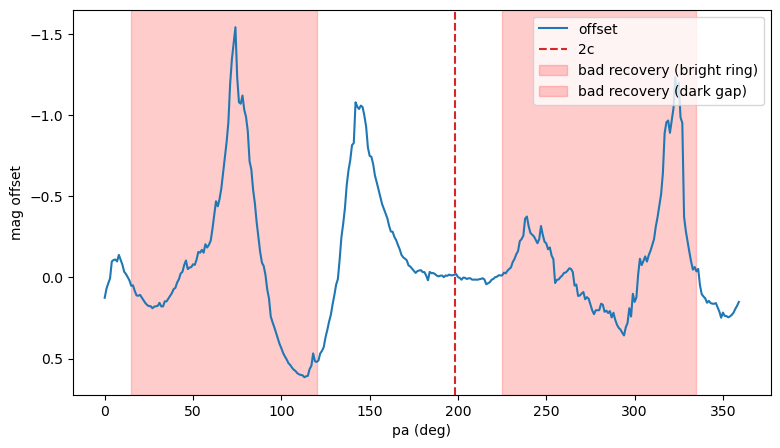

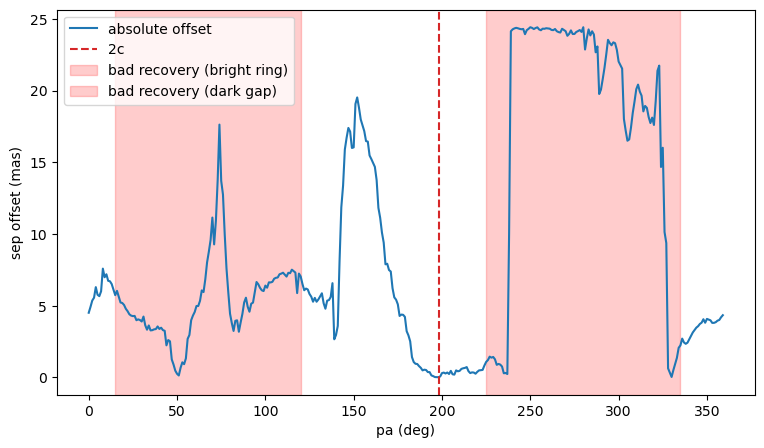

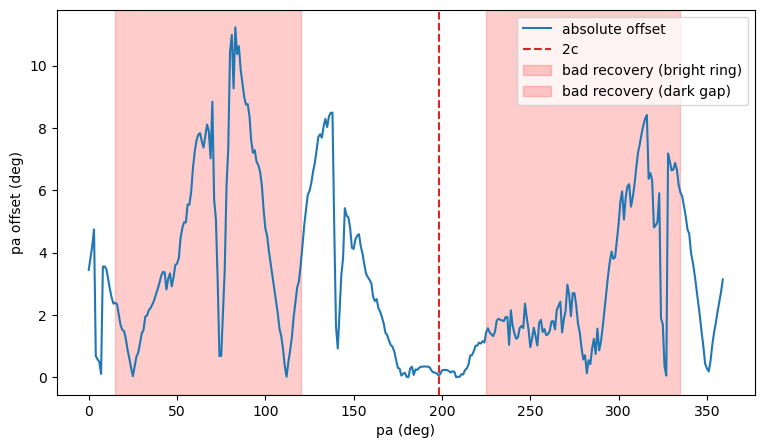

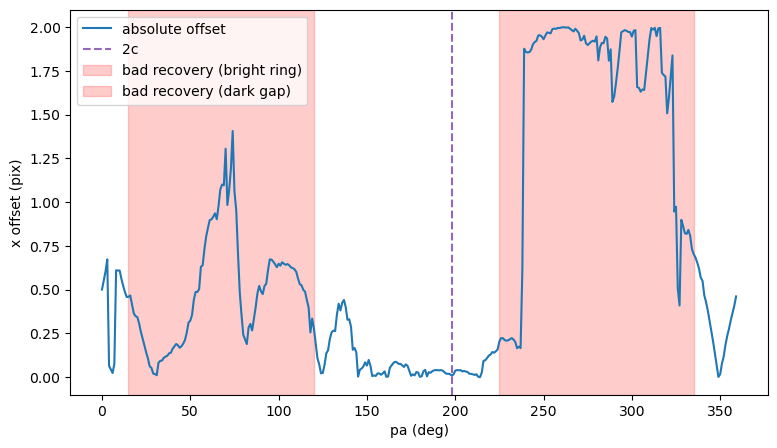

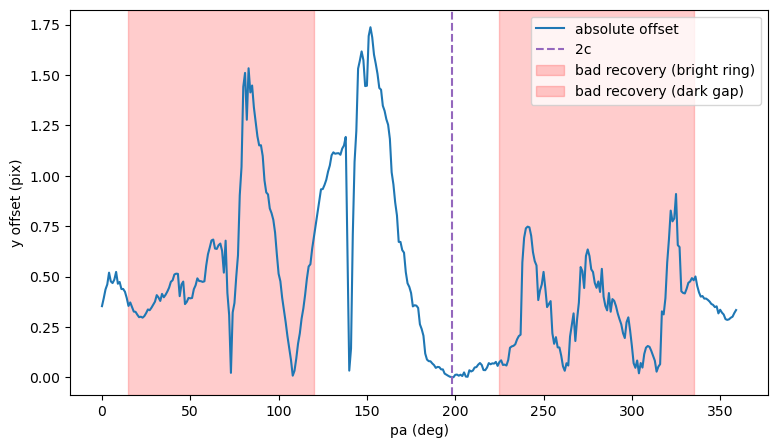

In [11]:
# plot errors as a function of angle
fig, ax = plt.subplots(1, figsize=(9,5))
for i in range(len(labels)):
    ax.plot(degrees, np.abs(offset[:,i]), label=labels[i])
plt.legend()
plt.show()
ang = pauf_n.n

fig, ax = plt.subplots(1, figsize=(10,5))
for i in range(3):
    ax.plot(degrees, np.abs(offset[:,i])/np.max(np.abs(offset[:,i])), label="normalised "+labels2[i]+" offset")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=15, xmax=120, color="purple", alpha=0.1, label="bad recovery (dark gap)")
ax.axvspan(xmin=225, xmax=335, color="pink", alpha=0.2, label="bad recovery (bright ring)")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("normalised offset")
plt.legend(bbox_to_anchor=(0.5, 1.05))
plt.show()

# just mag
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,2]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("mag offset")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")

ax.legend()
plt.show()

# just mag
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, offset[:,2], label="offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("mag offset")
ax.invert_yaxis()
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")

ax.legend()
plt.show()

# just sep
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,0])*1000, label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("sep offset (mas)")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()

# just pa
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,1]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("pa offset (deg)")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()

# just x
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,3]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("x offset (pix)")
ax.axvline(x=ang, ls="--", c="C4", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()

# just y
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,4]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("y offset (pix)")
ax.axvline(x=ang, ls="--", c="C4", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()



In [12]:
sep_percen = np.percentile(offset[:, 0], [16.0, 50.0, 84.0])
ang_percen = np.percentile(offset[:, 1], [16.0, 50.0, 84.0])
mag_percen = np.percentile(offset[:, 2], [16.0, 50.0, 84.0])
x_pos_percen = np.percentile(offset[:, 3], [16.0, 50.0, 84.0])
y_pos_percen = np.percentile(offset[:, 4], [16.0, 50.0, 84.0])

print("\nMedian offset and uncertainties:")

print(
    f"   - Position x (pixels) = {x_pos_percen[1]:.2f} "
    f"(-{x_pos_percen[1]-x_pos_percen[0]:.2f} "
    f"+{x_pos_percen[2]-x_pos_percen[1]:.2f})"
)

print(
    f"   - Position y (pixels) = {y_pos_percen[1]:.2f} "
    f"(-{y_pos_percen[1]-y_pos_percen[0]:.2f} "
    f"+{y_pos_percen[2]-y_pos_percen[1]:.2f})"
)

print(
    f"   - Separation (mas) = {1e3*sep_percen[1]:.2f} "
    f"(-{1e3*sep_percen[1]-1e3*sep_percen[0]:.2f} "
    f"+{1e3*sep_percen[2]-1e3*sep_percen[1]:.2f})"
)

print(
    f"   - Position angle (deg) = {ang_percen[1]:.2f} "
    f"(-{ang_percen[1]-ang_percen[0]:.2f} "
    f"+{ang_percen[2]-ang_percen[1]:.2f})"
)

print(
    f"   - Contrast (mag) = {mag_percen[1]:.2f}"
    f"(-{mag_percen[1]-mag_percen[0]:.2f} "
    f"+{mag_percen[2]-mag_percen[1]:.2f})"
)


Median offset and uncertainties:
   - Position x (pixels) = -0.18 (-1.70 +0.37)
   - Position y (pixels) = -0.16 (-0.33 +0.77)
   - Separation (mas) = -3.47 (-18.46 +8.82)
   - Position angle (deg) = 0.11 (-3.51 +4.77)
   - Contrast (mag) = -0.02(-0.41 +0.23)


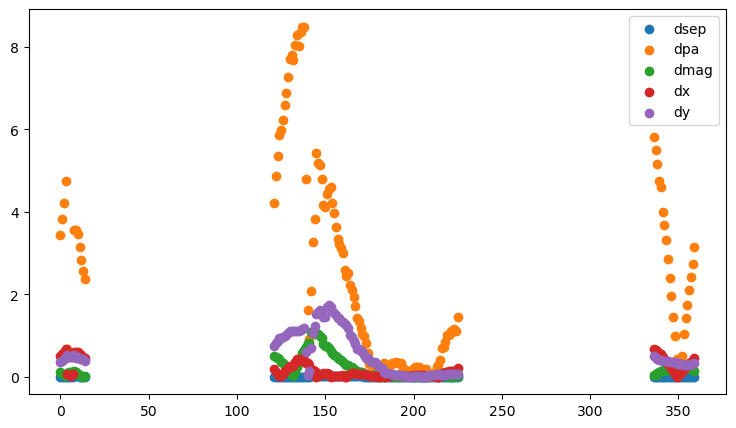


Median offset_cut and uncertainties:
   - Position x (pixels) = 0.02 (-0.09 +0.30)
   - Position y (pixels) = 0.03 (-0.50 +0.85)
   - Separation (mas) = -3.18 (-7.05 +3.68)
   - Position angle (deg) = 0.02 (-3.37 +3.16)
   - Contrast (mag) = -0.01(-0.39 +0.17)


In [13]:
#t1 = np.logical_and(offset>=0, offset<=15)
degrees_mask = np.logical_or.reduce((np.logical_and(degrees>=0, degrees<15), np.logical_and(degrees>120, degrees<=225), np.logical_and(degrees>335, degrees<=360)))
offset_cut = offset[degrees_mask]
degrees_cut = degrees[degrees_mask]
#print(offset_cut)


# plot errors as a function of angle
fig, ax = plt.subplots(1, figsize=(9,5))
for i in range(len(labels)):
    ax.scatter(degrees_cut, np.abs(offset_cut[:,i]), label=labels[i])
plt.legend()
plt.show()

sep_percen = np.percentile(offset_cut[:, 0], [16.0, 50.0, 84.0])
ang_percen = np.percentile(offset_cut[:, 1], [16.0, 50.0, 84.0])
mag_percen = np.percentile(offset_cut[:, 2], [16.0, 50.0, 84.0])
x_pos_percen = np.percentile(offset_cut[:, 3], [16.0, 50.0, 84.0])
y_pos_percen = np.percentile(offset_cut[:, 4], [16.0, 50.0, 84.0])

print("\nMedian offset_cut and uncertainties:")

print(
    f"   - Position x (pixels) = {x_pos_percen[1]:.2f} "
    f"(-{x_pos_percen[1]-x_pos_percen[0]:.2f} "
    f"+{x_pos_percen[2]-x_pos_percen[1]:.2f})"
)

print(
    f"   - Position y (pixels) = {y_pos_percen[1]:.2f} "
    f"(-{y_pos_percen[1]-y_pos_percen[0]:.2f} "
    f"+{y_pos_percen[2]-y_pos_percen[1]:.2f})"
)

print(
    f"   - Separation (mas) = {1e3*sep_percen[1]:.2f} "
    f"(-{1e3*sep_percen[1]-1e3*sep_percen[0]:.2f} "
    f"+{1e3*sep_percen[2]-1e3*sep_percen[1]:.2f})"
)

print(
    f"   - Position angle (deg) = {ang_percen[1]:.2f} "
    f"(-{ang_percen[1]-ang_percen[0]:.2f} "
    f"+{ang_percen[2]-ang_percen[1]:.2f})"
)

print(
    f"   - Contrast (mag) = {mag_percen[1]:.2f}"
    f"(-{mag_percen[1]-mag_percen[0]:.2f} "
    f"+{mag_percen[2]-mag_percen[1]:.2f})"
)


In [14]:
# total mag uncertainty

mag_sys_mean_err = 0.5 * (np.abs(mag_percen[1]-mag_percen[0]) + np.abs(mag_percen[2]-mag_percen[1]))
mag_sys_max_err = np.max([np.abs(mag_percen[1]-mag_percen[0]), np.abs(mag_percen[2]-mag_percen[1])])
print("sys", mag_sys_mean_err, mag_sys_max_err)

err_mean_comb = np.sqrt(mag_mean_err**2 + mag_sys_mean_err**2)
err_max_comb = np.sqrt(mag_max_err**2 + mag_sys_max_err**2)

print("\nnpca", pca_number)
print("mag contrast", mag_contrast)
print("tot mean err", err_mean_comb)
print("tot max err", err_max_comb)

pa_sys_max_err = np.max([np.abs(ang_percen[1]-ang_percen[0]), np.abs(ang_percen[2]-ang_percen[1])])
print("sys pa max", pa_sys_max_err)

err_max_comb_pa = np.sqrt(pa_max_err**2 + pa_sys_max_err**2)
print("pa", pa)
print("pa err comb", err_max_comb_pa)

sep_sys_max_err = 1e3 * np.max([np.abs(sep_percen[1]-sep_percen[0]), np.abs(sep_percen[2]-sep_percen[1])])
print("sys", sep_sys_max_err)

err_max_comb_sep = np.sqrt(sep_max_err**2 + sep_sys_max_err**2)
print("sep", sep)
print("sep err comb", err_max_comb_sep)

magnitude_contrast = ufloat(mag_contrast, err_max_comb)
print("contrast", magnitude_contrast)

star_H = ufloat(8.591, 0.078)
print("star H", star_H)
parallax = ufloat(7.464925176349439, 0.021432146)
distance = 1000/parallax

planet_app_mag = magnitude_contrast + star_H
print("app mag", planet_app_mag)

planet_abs_mag = 5 - 5*umath.log10(distance) + planet_app_mag

print("abs mag", planet_abs_mag)


sys 0.2788961499121958 0.38758919439070505

npca 12
mag contrast 7.811761624105217
tot mean err 0.2789869887335822
tot max err 0.3876586046701588
sys pa max 3.3659484582464256
pa 198.38256628944004
pa err comb 3.369099368938527
sys 7.051421351054892
sep 97.69224334917578
sep err comb 7.053629444571056
contrast 7.8+/-0.4
star H 8.59+/-0.08
app mag 16.4+/-0.4
abs mag 10.8+/-0.4


In [15]:
print("systematic pa and sep errors")
print(pa_sys_max_err)
print(1e-3*sep_sys_max_err)
print("original pa and sep")
print(pauf_n)
print(sepuf_n)

#combine
pauf_n_comb = pauf_n + ufloat(0, pa_sys_max_err)
sepuf_n_comb = sepuf_n + ufloat(0, 1e-3*sep_sys_max_err)
print("combined pa and sep")
print(pauf_n_comb)
print(sepuf_n_comb)

systematic pa and sep errors
3.3659484582464256
0.007051421351054892
original pa and sep
198.4+/-1.9
0.0977+/-0.0023
combined pa and sep
198+/-4
0.098+/-0.007


In [16]:
print("sep:", sepuf_n_comb.n * 1e3, "+/-", sepuf_n_comb.s*1e3)
print("pa:", pauf_n_comb.n, "+/-", pauf_n_comb.s)
print("planet contrast:", magnitude_contrast.n,"+/-", magnitude_contrast.s)
print("planet apparent magnitude:", planet_app_mag.n,"+/-", planet_app_mag.s)
print("planet absolute mag:", planet_abs_mag.n, "+/-", planet_abs_mag.s)


sep: 97.69224334917578 +/- 7.420750510101014
pa: 198.38256628944 +/- 3.845649429767953
planet contrast: 7.811761624105217 +/- 0.3876586046701588
planet apparent magnitude: 16.402761624105217 +/- 0.39542786165723637
planet absolute mag: 10.76788891906455 +/- 0.3954770050101235


In [17]:
# plot image
# read fits
rdi = fits.getdata(f'{output_place}/rdi.fits')
print(rdi.shape)

(51, 101, 101)


In [38]:
def plot_imshow(im, xlabel="x [pixels]", ylabel="y [pixels]", plottitle=None, vmin=None, vmax=None, figsize=(5,5), extent=None, norm=None, r_trim=0, cbarlabel="count", r_trim_c=(0,0), r_box="odd", r_circ=0, r_circ_c=(0,0), cmap="viridis", pixscale=1, zoom=True, fig=None, ax=None):
    """Plot imshow of im
    Optionally provide different axlabels and cbarlabel (default is x [pixels], y [pixels], count)
    Optionally provide plottitle, default is None
    Optionally provide vmin and vmax
    Optionally provide figsize
    Optionally adjust extent
    Optionally cut out center square with diameter 2*trim + 1, by default if r_trim is provided, around center of image
    - if r_trim_c is provided, then the center of the square is at r_trim_c
    - default of box is odd (same amount of pixels on all side of center)
    - optionally change to even to have n pixels left/below center and n-1 right/above center
    Optionally draw a circle with radius r_circ, by default if r_circ is provided, around center of image
    - if r_circ_c is provided, then the center of the circle is at r_circ_c
    """
    im2 = im.copy()
    if r_trim>0:
        if r_trim_c == (0,0):
            (nx,ny) = im.shape
            cx = int((nx-1) / 2)
            cy = int((nx-1) / 2)
        else:
            (cx, cy) = r_trim_c
        if r_box=="even":
            im2 = im2[cy-r_trim:cy+r_trim,cx-r_trim:cx+r_trim]
        else:
            im2 = im2[cy-r_trim:cy+r_trim+1,cx-r_trim:cx+r_trim+1]
    if ax is None:
        fig, ax = plt.subplots(1, figsize=figsize)
        fig.suptitle(plottitle, fontsize=16)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if r_circ>0:
        (nx2, ny2) = im2.shape
        if r_circ_c == (0,0):
            cx2 = int((nx2-1) / 2)
            cy2 = int((nx2-1) / 2)
        else:
            (cx2, cy2) = r_circ_c
        circle = plt.Circle((cx2,cy2), r_circ, color='red', fill=True, lw=2)
        ax.add_patch(circle)
    #extlim = int((im2.shape[0] - 1) / 2)
    extlim = (im2.shape[0]) / 2
    extent = [extlim*pixscale, -extlim*pixscale, -extlim*pixscale, extlim*pixscale]
    image = ax.imshow(im2, vmin=vmin, vmax=vmax, extent=extent, norm=norm, cmap=cmap, origin='lower')
    #plt.colorbar(image, ax=ax, label=cbarlabel, fraction=0.0453)
    #plt.tight_layout()
    #plt.show()
    #plt.close(fig)
    if zoom == True:
        ax.set_xlim(0.2, -0.2)
        ax.set_ylim(-0.2, 0.2)
        #ax.set_xlim(1, -3)
        #ax.set_ylim(-3, 1)
    ax.set_aspect('equal')
    return fig, ax, image


In [39]:
def seppa_to_offset(sep, pa):
    pixscale = 0.01225
    pa_rad = pa * np.pi / 180.
    theta = pa_rad - np.pi
    r = sep / pixscale
    dx = r * umath.sin(theta)
    dy = -r * umath.cos(theta)
    return dx, dy


xoff, yoff = seppa_to_offset(1e-3*sep, pa)

print(xoff, yoff)

# cmap
from cmap import Colormap
from matplotlib.colors import ListedColormap
cm = Colormap('cmasher:freeze')  # case insensitive
n = 512
a = 0.9999  # lower is more black
c = 0.0001  # higher is more pastel / lighter -- I2
cmap_ini = cm(np.arange(cm.num_colors))
cmap_ini[:, 0:3] *= a
cmap_edit1 = ListedColormap(cmap_ini)
cmap_ini2 = cmap_edit1.resampled(512)
newcmaplist = (1. - c) * cmap_ini2(np.linspace(0.0, 1.0, n)) + c * np.ones((n, 4))
newcmp = ListedColormap(newcmaplist)

mapnametest = newcmp

img = rdi[pca_number-1]


2.5149596254682187 -7.56793508009435


In [77]:
import matplotlib as mpl
purple_paper = '#663399'
pixscale = 0.01225
fig, ax = plt.subplots(figsize=(5,5))
#vmin = np.percentile(img, 0.1)    # nf2
#vmax = np.percentile(img, 99.65)    # if masked
vmin = -800
vmax = 1100
# presentation values
#vmin = -600
#vmax = 800
fig, ax, implot = plot_imshow(img, ax=ax,
                cmap=mapnametest, vmin=vmin, vmax=vmax, pixscale=pixscale,
                xlabel=r'$\Delta$RA (arcsec)', ylabel=r'$\Delta$Dec (arcsec)', zoom=True)
mpl.rcParams['hatch.linewidth'] = 2.0
circle = plt.Circle((0,0), 5*pixscale, facecolor='lightgrey', edgecolor='navy', fill=True, lw=2, hatch='////')
#ax.add_patch(circle)

# sphere coro
ax.text(-0.1, 0, '50%', color='red', fontsize=18, fontweight="bold")
circle = plt.Circle((0,0), 8*pixscale, edgecolor='red', fill=False, lw=2, ls="--")
ax.add_patch(circle)

# around candidate
circle = plt.Circle((-(xoff)*pixscale,yoff*pixscale), 4*pixscale, facecolor='lightgrey', edgecolor='white', fill=False, lw=2, linestyle="dotted")
ax.add_patch(circle)

def save_figure(fig, outfile='figures/uncategorised/image', ext="png", tl=False, dpi=300, nopad=False):
    """Save figure to file with filename in subdirectory subdir.
    Default filename is xy
    Default subdirectory is uncategorised
    Default dpi = 300
    Default extension is .png
    """
    #Path(outdir).mkdir(parents=True, exist_ok=True)  # make sure subdirectory figures exists
    if tl==True:
        plt.tight_layout()
    if nopad==True:
        plt.savefig(f'{outfile}.{ext}', dpi=dpi, bbox_inches='tight', pad_inches=0)
    else:
        plt.savefig(f'{outfile}.{ext}', dpi=dpi, bbox_inches='tight')
    plt.close(fig)

save_figure(fig, outfile=f'{output_place}/sphere_coro', dpi=600, ext="pdf", nopad=True)
#save_figure(fig, outfile=f'{output_place}/sphere', dpi=600, ext="pdf", nopad=True)
#plt.show()

